<a href="https://colab.research.google.com/github/Yelmi95/IA_SIS420/blob/main/Lab04__no_grafico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 4 — Clasificación  No grafico

Nombre:Yulitza Alcibia Miranda

Grupo:2

### Dataset: Lending Club Credit Risk (2007-2015)
Lending Club es una plataforma estadounidense de préstamos entre personas (peer-to-peer lending).
Este dataset contiene información de préstamos otorgados entre 2007 y 2015, donde cada préstamo
tiene asignado un **grado de riesgo crediticio** (A-E) que indica la probabilidad de que el
prestatario no pague su deuda.

URL: https://drive.google.com/file/d/11tksiJQ41YGcJl-cKdxxiwf33VjV_n4b/view?usp=sharing

### Descripción del problema
Se implementa un clasificador multiclase utilizando **Regresión Logística One-vs-All (OvA)**
sin usar librerías de machine learning de alto nivel, siguiendo la metodología del curso.
El objetivo es predecir el grado de riesgo (A, B, C, D o E) de un préstamo a partir
de sus características financieras.

### Características del experimento
- **Observaciones originales:** 829,768
- **Features utilizados:** 40 (31 numéricos + 9 categóricos)
- **Clases objetivo:** 5 (A, B, C, D, E = grado de riesgo crediticio)
- **Balanceo:** Undersampling → 21,000 por clase = 105,000 total
- **División:** 80% entrenamiento / 20% prueba

## Paso 1: Importar librerías y Montar Google Drive

In [1]:
import os

import numpy as np

from matplotlib import pyplot

from scipy import optimize

import pandas as pd
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Paso 2: Cargar el dataset y Filtrar clases válidas

Se carga el dataset original de Lending Club y se filtran únicamente los préstamos con grado **A, B, C, D o E**.
Estas letras representan el nivel de riesgo crediticio asignado por la plataforma:
- **A** = menor riesgo (prestatarios más confiables)
- **E** = mayor riesgo (prestatarios con historial más riesgoso)

Se eliminan los grados F y G por tener muy pocas muestras en comparación con las demás clases.

In [3]:
df = pd.read_csv('/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/data.csv',
                 low_memory=False)
clases_validas = ['A', 'B', 'C', 'D', 'E']
df = df[df['grade'].isin(clases_validas)].copy()

print('Shape tras filtrar:', df.shape)
print('\nDistribución:')
print(df['grade'].value_counts())

Shape tras filtrar: (829768, 73)

Distribución:
grade
B    247998
C    236855
A    145665
D    132802
E     66448
Name: count, dtype: int64


## Paso 3: Seleccionar y preprocesar features

Se seleccionan **40 features** relevantes para predecir el grado de riesgo:
- **31 features numéricos**: montos, tasas, historial de pagos, etc.
- **9 features categóricos**: tipo de empleo, propósito del préstamo, estado, etc.

Las variables categóricas se codifican con `LabelEncoder` (valores enteros).
Los valores nulos se rellenan con la **mediana** de cada columna para no distorsionar la distribución.

La variable objetivo `grade` se mapea a enteros: A→0, B→1, C→2, D→3, E→4

In [4]:

cols_num = ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'installment',
            'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
            'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp',
            'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
            'total_rec_int', 'total_rec_late_fee', 'recoveries',
            'collection_recovery_fee', 'last_pymnt_amnt',
            'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt',
            'tot_cur_bal', 'total_rev_hi_lim', 'default_ind', 'policy_code',
            'int_rate']


cols_cat = ['term', 'emp_length', 'home_ownership', 'verification_status',
            'pymnt_plan', 'purpose', 'initial_list_status',
            'application_type', 'addr_state']

df_work = df[cols_num + cols_cat + ['grade']].copy()


grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
df_work['grade'] = df_work['grade'].map(grade_map)

le = LabelEncoder()
for col in cols_cat:
    df_work[col] = le.fit_transform(df_work[col].astype(str))

# Rellenar valores nulos con la mediana
df_work = df_work.fillna(df_work.median(numeric_only=True))

print('Features numéricas originales:', len(cols_num))
print('Features categóricas codificadas:', len(cols_cat))
print('Total features:', len(cols_num) + len(cols_cat))
print('Shape:', df_work.shape)


Features numéricas originales: 31
Features categóricas codificadas: 9
Total features: 40
Shape: (829768, 41)


## Paso 4: Balanceo de clases
El dataset original está desbalanceado (hay muchos más préstamos de clase A que E).
Para evitar que el modelo aprenda sesgado hacia las clases mayoritarias.Se toman exactamente **21,000 ejemplos por clase** de forma aleatoria.

Resultado: **105,000 ejemplos** distribuidos uniformemente entre las 5 clases.

In [5]:
N = 21000
frames = [df_work[df_work['grade'] == i].sample(n=N, random_state=42)
          for i in range(5)]
df_bal = pd.concat(frames).sample(frac=1, random_state=42).reset_index(drop=True)


print('\nDistribución balanceada:')
print(df_bal['grade'].value_counts().sort_index())
print('Total:', len(df_bal))


Distribución balanceada:
grade
0    21000
1    21000
2    21000
3    21000
4    21000
Name: count, dtype: int64
Total: 105000


## Paso 5: Convertir DataFrame a arrays NumPy

Se extraen directamente las features y etiquetas del DataFrame balanceado
usando nombres de columna.

In [20]:
input_layer_size = 40
num_labels = 5
clase_map_inv = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
N_POR_CLASE = 21000

X = df_bal.drop(columns=['grade']).values
y = df_bal['grade'].values

m = y.size

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('Total ejemplos m =', m)
print('Primer ejemplo X[0]:', X[0, :])
print('Etiquetas y:', y)

Shape X: (105000, 40)
Shape y: (105000,)
Total ejemplos m = 105000
Primer ejemplo X[0]: [1.050000e+04 1.050000e+04 1.050000e+04 3.788700e+02 3.500000e+04
 1.955000e+01 0.000000e+00 1.000000e+00 1.000000e+01 0.000000e+00
 1.548100e+04 4.780000e+01 1.100000e+01 1.027741e+04 1.027741e+04
 3.580300e+02 3.580300e+02 2.225900e+02 1.354400e+02 0.000000e+00
 0.000000e+00 0.000000e+00 3.788700e+02 0.000000e+00 0.000000e+00
 0.000000e+00 2.762100e+04 3.240000e+04 0.000000e+00 1.000000e+00
 1.786000e+01 0.000000e+00 4.000000e+00 5.000000e+00 2.000000e+00
 0.000000e+00 2.000000e+00 0.000000e+00 0.000000e+00 3.100000e+01]
Etiquetas y: [3 2 1 ... 4 0 0]


## Paso 6: División 80% entrenamiento / 20% prueba

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Entrenamiento:', X_train.shape, '→', len(X_train), 'ejemplos')
print('Prueba:       ', X_test.shape,  '→', len(X_test),  'ejemplos')

Entrenamiento: (84000, 40) → 84000 ejemplos
Prueba:        (21000, 40) → 21000 ejemplos


## Paso 7: Normalización de features

In [8]:
def featureNormalize(X):
    X_norm = X.copy().astype(float)
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


In [9]:
# Normalizar usando parámetros del entrenamiento
X_norm, mu, sigma = featureNormalize(X_train)

# Aplicar misma normalización al test
sigma[sigma == 0] = 1
X_test_norm = (X_test - mu) / sigma

print(X_norm[0,:])
print(y_train)

[ 0.32723369  0.32908337  0.33242261  0.05853592 -0.55978541  0.32924854
  1.90940148  0.29431105 -0.29970072 -0.32748935 -0.40583758  0.04951036
 -0.70156235  1.04620118  1.04712083 -0.90361467 -0.90274019 -0.82792808
 -0.72854881 -0.09115108 -0.12418796 -0.0852804  -0.35997929 -0.11209587
 -0.06734181 -0.11179013 -0.72261703 -0.40289005 -0.24886438  0.
  0.99543665  1.39804201 -0.8664583   1.09607404 -0.06615132 -0.00345035
 -0.26556444  1.03472149 -0.02182699 -1.45441575]
[4 0 2 ... 4 3 1]


In [10]:
# Configurar la matriz X con los datos normalizados de entrenamiento
m, n = X_norm.shape
X = X_norm

print('Shape X entrenamiento:', X.shape)
print('Shape y_train:', y_train.shape)

Shape X entrenamiento: (84000, 40)
Shape y_train: (84000,)


## Paso 8: Implementación del modelo - Regresión Logística One-vs-All

Se implementan las tres funciones core del modelo desde cero:

- **`sigmoid(z)`**: transforma cualquier valor real al rango (0,1), interpretándose como probabilidad. Se usa `np.clip` para evitar overflow numérico.
- **`lrCostFunction`**: calcula el costo J(θ) con regularización L2 y su gradiente vectorizado. El término de bias θ₀ no se regulariza.
- **`oneVsAll`**: entrena K=5 clasificadores binarios, uno por clase. En cada uno convierte el problema a "clase actual vs. todas las demás" y minimiza el costo con el optimizador CG de scipy.

**`predictOneVsAll`**: una vez entrenados los 5 clasificadores, evalúa cada ejemplo contra todos ellos y asigna la clase con mayor probabilidad usando `argmax`.



In [11]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

In [12]:
def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-10, 1 - 1e-10)

    reg = (lambda_ / (2 * m)) * np.sum(theta[1:] ** 2)
    J = (1/m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) + reg

    grad = (1/m) * X.T.dot(h - y)
    grad[1:] += (lambda_ / m) * theta[1:]

    return J, grad

In [13]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    costos_por_clase = []

    # Agrega unos a la matriz X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        historial = []

        def callback(theta):
            J, _ = lrCostFunction(theta, X, (y == c).astype(float), lambda_)
            historial.append(J)

        options = {'maxiter': 200}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c).astype(float), lambda_),
                                jac=True,
                                method='CG',
                                callback=callback,
                                options=options)

        all_theta[c] = res.x
        costos_por_clase.append(historial)
        print(f'Clase {c} - Costo final: {res.fun:.6f}')

    return all_theta, costos_por_clase

In [14]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Agregar unos a la matriz X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

In [15]:
lambda_ = 0.1
all_theta, costos_por_clase = oneVsAll(X, y_train, num_labels, lambda_)
print(all_theta.shape)

Clase 0 - Costo final: 0.041965
Clase 1 - Costo final: 0.433529
Clase 2 - Costo final: 0.491715
Clase 3 - Costo final: 0.423804
Clase 4 - Costo final: 0.109995
(5, 41)


In [16]:
print(all_theta)

[[-2.52174053e+01 -4.32945788e-01  6.52857763e-01  5.50300521e-01
  -1.57360159e+00  2.89944770e-02 -1.46458213e-01 -1.92001635e-01
   4.82425845e-02 -1.23717241e-01 -2.31151442e-01 -7.37220621e-02
  -1.97682910e-01  5.99404939e-02 -2.12102946e-01 -8.18047248e-02
   1.31187810e+00  2.23815616e-01  1.42573044e+00  3.79104768e-01
  -2.64216884e-03  1.57573765e-01 -1.95548483e-01 -1.17072269e+00
  -8.38796637e-02 -1.54692799e-01 -6.81749717e-02 -8.61857287e-03
   3.07128741e-01  6.13408574e-01  0.00000000e+00 -2.24527301e+01
  -8.30245402e-01 -3.67409173e-02 -4.20135329e-02  5.17099580e-02
   6.22956802e-02  1.09555084e-02  5.42582909e-02  4.99808958e-02
  -1.32089703e-02]
 [-1.70194286e+00 -5.69642066e-01  1.55973971e+00  5.37766759e-01
  -1.73655239e+00 -5.80169501e-02 -2.14908131e-02  7.97276377e-02
  -2.17813355e-02  8.04819078e-02  6.92776428e-02  2.47016070e-01
   1.49222179e-01 -8.96447996e-03  4.89996249e-02  1.24102158e-01
   2.86359336e-01 -2.14814377e-01  3.71921322e-01 -1.0306

## Paso 10: Curvas de Convergencia

Se grafica el historial de la función de costo $J(\theta)$ a lo largo de las iteraciones
para cada uno de los 5 clasificadores.

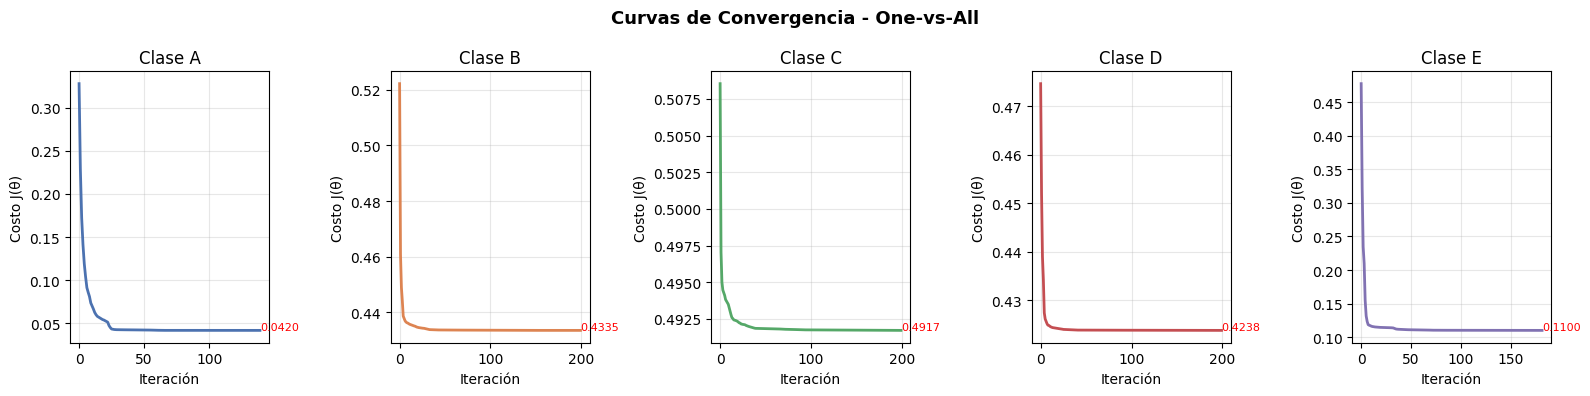

In [17]:
nombres_clases = ['A', 'B', 'C', 'D', 'E']
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

pyplot.figure(figsize=(16, 4))
for c in range(num_labels):
    pyplot.subplot(1, 5, c+1)
    pyplot.plot(costos_por_clase[c], color=colores[c], linewidth=2)
    pyplot.title(f'Clase {nombres_clases[c]}')
    pyplot.xlabel('Iteración')
    pyplot.ylabel('Costo J(θ)')
    pyplot.grid(True, alpha=0.3)
    if costos_por_clase[c]:
        pyplot.annotate(f'{costos_por_clase[c][-1]:.4f}',
                       xy=(len(costos_por_clase[c])-1, costos_por_clase[c][-1]),
                       fontsize=8, color='red')

pyplot.suptitle('Curvas de Convergencia - One-vs-All', fontsize=13, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

## Paso 11: Evaluación del modelo

Se mide la **precisión (accuracy)** en ambos conjuntos:
- **Precisión en entrenamiento**: qué tan bien clasifica los datos con los que aprendió
- **Precisión en prueba**: qué tan bien generaliza a datos nuevos que nunca vio

In [18]:
# Precisión en entrenamiento
pred_train = predictOneVsAll(all_theta, X)
print('Precisión del conjunto de entrenamiento: {:.2f}%'.format(np.mean(pred_train == y_train) * 100))

# Precisión en prueba
pred_test = predictOneVsAll(all_theta, X_test_norm)
print('Precisión del conjunto de prueba:        {:.2f}%'.format(np.mean(pred_test == y_test) * 100))

Precisión del conjunto de entrenamiento: 80.89%
Precisión del conjunto de prueba:        80.63%


## Paso 12: Predicciones individuales de ejemplo

Se seleccionan **15 ejemplos aleatorios** del conjunto de prueba para verificar
visualmente las predicciones del modelo.

Para cada ejemplo se muestra:
- El índice del ejemplo en el conjunto de prueba
- La clase **real** (letra A-E)
- La clase **predicha** por el modelo
- Si la predicción fue correcta (✓) o incorrecta (✗)

Al final se presenta un resumen completo del experimento.

In [22]:
print('PREDICCIONES EN EJEMPLOS DEL CONJUNTO DE PRUEBA')
print('='*60)
print(f'{"Ejemplo":<10} {"Real":<10} {"Predicho":<10} {"Correcto"}')
print('-'*60)

np.random.seed(42)
indices = np.random.choice(len(y_test), 15, replace=False)

for idx in indices:
    real     = clase_map_inv[y_test[idx]]
    predicho = clase_map_inv[pred_test[idx]]
    correcto = '✓' if real == predicho else '✗'
    print(f'{idx:<10} {real:<10} {predicho:<10} {correcto}')



PREDICCIONES EN EJEMPLOS DEL CONJUNTO DE PRUEBA
Ejemplo    Real       Predicho   Correcto
------------------------------------------------------------
2312       A          A          ✓
16845      B          B          ✓
6105       E          E          ✓
18082      A          A          ✓
11335      A          A          ✓
17677      B          B          ✓
1092       A          A          ✓
8364       E          E          ✓
18550      D          D          ✓
11423      E          E          ✓
6757       A          A          ✓
12893      E          D          ✗
17446      E          E          ✓
11823      B          B          ✓
4772       C          C          ✓
